Step 1: Load & Initial EDA — Understanding the Political Landscape

Goal: Before any LGBTQ+ filtering, understand the partisan "atmosphere" 
of each state-session from the full 750k bill dataset.

In [1]:
import pandas as pd
import numpy as np
import re

In [2]:
# Read in Bills Data
df = pd.read_csv('../legiscan-joined-all/all_bills_2021_2026.csv')

In [3]:
print(f"Total bills: {len(df):,}")
print(f"States: {df['state'].nunique()}")
print(f"\nColumns:\n{df.dtypes}")

Total bills: 746,696
States: 53

Columns:
state                  object
bill_id                 int64
session_id              int64
bill_number            object
status                  int64
status_desc            object
status_date            object
title                  object
description            object
committee_id            int64
committee              object
last_action_date       object
last_action            object
url                    object
state_link             object
sponsor_names          object
sponsor_parties        object
primary_sponsor        object
sponsor_count           int64
action_count            int64
last_history_action    object
document_count          int64
document_types         object
document_urls          object
rollcall_count          int64
total_yea               int64
total_nay               int64
dtype: object


In [4]:
# Data quality checks
print("\n--- Missing Values (top columns) ---")
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False).head(15))

print("\n--- Status Distribution ---")
print(df['status_desc'].value_counts())

print("\n--- Bills per State (top 10) ---")
print(df['state'].value_counts().head(10))

df['year'] = pd.to_datetime(df['status_date']).dt.year
df['year'] = df['year'].fillna(df['year']).astype('Int64')


--- Missing Values (top columns) ---
committee              334662
sponsor_parties         28581
primary_sponsor          4763
sponsor_names            4759
document_types           2862
document_urls            2862
status_desc              1625
status_date              1625
last_history_action       930
last_action               928
last_action_date          920
title                       1
dtype: int64

--- Status Distribution ---
status_desc
Introduced    474264
Passed        168107
Failed         50395
Engrossed      45691
Vetoed          4309
Enrolled        2305
Name: count, dtype: int64

--- Bills per State (top 10) ---
state
NY            68400
NJ            65270
TX            37746
USCongress    37121
IL            34278
HI            29419
MN            28006
OK            27008
TN            26147
MA            24673
Name: count, dtype: int64


In [5]:
def parse_party_counts(party_str):
    """Parse 'R | D | R | R' into party counts."""
    if pd.isna(party_str):
        return {'R': 0, 'D': 0, 'Other': 0}

    parties = [p.strip() for p in str(party_str).split('|')]
    counts = {
        'R': sum(1 for p in parties if p == 'R'),
        'D': sum(1 for p in parties if p == 'D'),
        'Other': sum(1 for p in parties if p not in ('R', 'D'))
    }
    return counts


# Apply and expand into columns
party_counts = df['sponsor_parties'].apply(parse_party_counts).apply(pd.Series)
df['r_sponsors'] = party_counts['R']
df['d_sponsors'] = party_counts['D']
df['other_sponsors'] = party_counts['Other']


# Derive the dominant party for each bill
def dominant_party(row):
    if row['r_sponsors'] > row['d_sponsors']:
        return 'R'
    elif row['d_sponsors'] > row['r_sponsors']:
        return 'D'
    elif row['r_sponsors'] == 0 and row['d_sponsors'] == 0:
        return 'Other'
    else:
        return 'Bipartisan'


df['bill_dominant_party'] = df.apply(dominant_party, axis=1)

print("\n--- Bill Dominant Party Distribution ---")
print(df['bill_dominant_party'].value_counts())
print(f"\nBipartisan bills: {(df['bill_dominant_party'] == 'Bipartisan').sum():,} "
      f"({(df['bill_dominant_party'] == 'Bipartisan').mean():.1%})")


--- Bill Dominant Party Distribution ---
bill_dominant_party
D             375646
R             307175
Other          34531
Bipartisan     29344
Name: count, dtype: int64

Bipartisan bills: 29,344 (3.9%)


In [6]:
df['passed'] = df['status'].isin([4])  # Only fully passed
df['failed'] = df['status'].isin([6])
df['vetoed'] = df['status'].isin([5])

print("\n--- Overall Pass Rates ---")
print(f"Passed: {df['passed'].mean():.1%}")
print(f"Failed/Dead: {df['failed'].mean():.1%}")
print(f"Vetoed: {df['vetoed'].mean():.1%}")
print(
    f"Still in process / other: {(~df['passed'] & ~df['failed'] & ~df['vetoed']).mean():.1%}")

# Pass rate by dominant party
print("\n--- Pass Rate by Bill's Dominant Party ---")
print(df.groupby('bill_dominant_party')['passed'].agg(['mean', 'count'])
      .rename(columns={'mean': 'pass_rate', 'count': 'n_bills'})
      .sort_values('n_bills', ascending=False))


--- Overall Pass Rates ---
Passed: 22.5%
Failed/Dead: 6.7%
Vetoed: 0.6%
Still in process / other: 70.2%

--- Pass Rate by Bill's Dominant Party ---
                     pass_rate  n_bills
bill_dominant_party                    
D                     0.195572   375646
R                     0.251215   307175
Other                 0.323912    34531
Bipartisan            0.214320    29344


In [7]:
print("\n--- Sample Bills with Parsed Sponsors ---")
cols_to_show = ['year', 'state', 'bill_number', 'title', 'status_desc',
                'r_sponsors', 'd_sponsors', 'bill_dominant_party', 'sponsor_count']
print(df[cols_to_show].head(10).to_string(index=False))


--- Sample Bills with Parsed Sponsors ---
 year state bill_number                                     title status_desc  r_sponsors  d_sponsors bill_dominant_party  sponsor_count
 2021    AK         HB1                  Audit Of Cares Act Funds  Introduced           5           1                   R              6
 2021    AK         HB2      Minimum Age To Sell Tobacco/nicotine  Introduced           1           0                   R              1
 2022    AK         HB3   Definition Of "disaster": Cybersecurity      Passed           8           1                   R             10
 2021    AK         HB4  Business/prof. License Immunity Covid-19  Introduced           7           0                   R              7
 2021    AK         HB5         Sexual Assault; Def. Of "consent"  Introduced           2          10                   D             13
 <NA>    AK         HB6                            Not Introduced         NaN           0           0               Other              

Step 2: State-Session Political Profiles

Goal: For each state-year, compute a political "atmosphere" profile
that captures partisan lean, legislative activity, and pass dynamics.

In [8]:
state_year_profiles = df.groupby(['state', 'year']).agg(
    # --- Volume ---
    total_bills=('bill_id', 'count'),

    # --- Partisan Sponsorship ---
    r_sponsored_bills=('bill_dominant_party', lambda x: (x == 'R').sum()),
    d_sponsored_bills=('bill_dominant_party', lambda x: (x == 'D').sum()),
    bipartisan_bills=('bill_dominant_party',
                      lambda x: (x == 'Bipartisan').sum()),

    # --- Pass Rates ---
    total_passed=('passed', 'sum'),

    # --- Sponsor Counts (avg engagement) ---
    avg_sponsor_count=('sponsor_count', 'mean'),
    avg_action_count=('action_count', 'mean'),
).reset_index()

# --- Derived Ratios ---

# Partisan lean: ratio of R-sponsored to total partisan bills
# Values > 0.5 = R-leaning legislature, < 0.5 = D-leaning
state_year_profiles['partisan_bills'] = (
    state_year_profiles['r_sponsored_bills'] +
    state_year_profiles['d_sponsored_bills']
)
state_year_profiles['r_sponsorship_ratio'] = (
    state_year_profiles['r_sponsored_bills'] /
    state_year_profiles['partisan_bills']
).fillna(0.5)  # Handle edge cases

# Overall pass rate
state_year_profiles['overall_pass_rate'] = (
    state_year_profiles['total_passed'] /
    state_year_profiles['total_bills']
)

# Bipartisan ratio: what fraction of bills have mixed sponsorship
state_year_profiles['bipartisan_ratio'] = (
    state_year_profiles['bipartisan_bills'] /
    state_year_profiles['total_bills']
)

print("\n--- State-Year Profile Sample ---")
cols = ['state', 'year', 'total_bills', 'r_sponsorship_ratio',
        'overall_pass_rate', 'bipartisan_ratio']
print(state_year_profiles[cols].head(10).to_string(index=False))


--- State-Year Profile Sample ---
state  year  total_bills  r_sponsorship_ratio  overall_pass_rate  bipartisan_ratio
   AK  2021          396             0.528302           0.123737          0.037879
   AK  2022          429             0.569930           0.256410          0.025641
   AK  2023          347             0.541485           0.129683          0.040346
   AK  2024          444             0.596296           0.182432          0.022523
   AK  2025          506             0.480938           0.108696          0.043478
   AK  2026           96             0.559322           0.010417          0.020833
   AL  2021         1614             0.821381           0.486369          0.021685
   AL  2022         1285             0.775200           0.499611          0.007782
   AL  2023         1323             0.780801           0.482237          0.000000
   AL  2024         1220             0.745180           0.534426          0.000000


In [9]:
def pass_rate_by_party(group):
    r_bills = group[group['bill_dominant_party'] == 'R']
    d_bills = group[group['bill_dominant_party'] == 'D']
    return pd.Series({
        'r_pass_rate': r_bills['passed'].mean() if len(r_bills) > 0 else np.nan,
        'd_pass_rate': d_bills['passed'].mean() if len(d_bills) > 0 else np.nan,
        'r_bill_count': len(r_bills),
        'd_bill_count': len(d_bills),
    })


party_pass = df.groupby(['state', 'year']).apply(
    pass_rate_by_party, include_groups=False
).reset_index()

# Merge into profiles
state_year_profiles = state_year_profiles.merge(
    party_pass, on=['state', 'year'])

# Pass rate gap: positive = R bills pass more, negative = D bills pass more
state_year_profiles['pass_rate_gap'] = (
    state_year_profiles['r_pass_rate'] - state_year_profiles['d_pass_rate']
)

print("\n--- Pass Rate Gap Distribution ---")
print(state_year_profiles['pass_rate_gap'].describe())


--- Pass Rate Gap Distribution ---
count    297.000000
mean       0.025933
std        0.195296
min       -0.774764
25%       -0.060872
50%        0.003738
75%        0.141207
max        0.553203
Name: pass_rate_gap, dtype: float64


In [10]:
def classify_state_lean(row):
    """
    Weight sponsorship ratio more heavily,
    use pass rate gap as secondary signal.
    """
    r_ratio = row['r_sponsorship_ratio']
    gap = row['pass_rate_gap']

    # Primary signal: who's introducing legislation
    if r_ratio > 0.7:
        return 'Strong R'
    elif r_ratio > 0.55:
        # Check if gap confirms or contradicts
        return 'Strong R' if gap > 0.1 else 'Lean R'
    elif r_ratio < 0.3:
        return 'Strong D'
    elif r_ratio < 0.45:
        return 'Strong D' if gap < -0.1 else 'Lean D'
    else:
        # True competitive: 0.45-0.55 sponsorship ratio
        if gap > 0.1:
            return 'Lean R'
        elif gap < -0.1:
            return 'Lean D'
        return 'Competitive'


state_year_profiles['state_lean'] = state_year_profiles.apply(
    classify_state_lean, axis=1)

print("\n--- State Lean Distribution ---")
print(state_year_profiles['state_lean'].value_counts())

# Show some examples
print("\n--- Example Strong R States ---")
strong_r = state_year_profiles[state_year_profiles['state_lean'] == 'Strong R']
print(strong_r[['state', 'year', 'r_sponsorship_ratio', 'pass_rate_gap']]
      .sort_values('pass_rate_gap', ascending=False).head(10).to_string(index=False))

print("\n--- Example Strong D States ---")
strong_d = state_year_profiles[state_year_profiles['state_lean'] == 'Strong D']
print(strong_d[['state', 'year', 'r_sponsorship_ratio', 'pass_rate_gap']]
      .sort_values('pass_rate_gap').head(10).to_string(index=False))


--- State Lean Distribution ---
state_lean
Strong R       114
Strong D       105
Lean R          44
Competitive     26
Lean D          26
Name: count, dtype: int64

--- Example Strong R States ---
state  year  r_sponsorship_ratio  pass_rate_gap
   UT  2022             0.886872       0.553203
   UT  2024             0.893921       0.527640
   UT  2023             0.886499       0.491446
   UT  2025             0.903737       0.459354
   OH  2026             0.831169       0.455529
   UT  2021             0.887770       0.443025
   ID  2023             0.842697       0.426667
   SD  2024             0.866029       0.418607
   ND  2021             0.880403       0.410250
   KS  2025             0.590604       0.400335

--- Example Strong D States ---
state  year  r_sponsorship_ratio  pass_rate_gap
   CO  2023             0.105185      -0.774764
   CO  2024             0.084088      -0.754694
   CO  2022             0.156835      -0.721593
   CO  2021             0.137195      -0.714684
 

In [11]:
print("\n--- Sanity Check: Known States (most recent year) ---")
latest = state_year_profiles.sort_values('year').groupby('state').last()
print(latest[['year', 'r_sponsorship_ratio', 'pass_rate_gap', 'state_lean']]
      .sort_values('r_sponsorship_ratio', ascending=False)
      .to_string())


--- Sanity Check: Known States (most recent year) ---
            year  r_sponsorship_ratio  pass_rate_gap   state_lean
state                                                            
ND          2026             1.000000       0.228060     Strong R
WY          2025             0.976303       0.264563     Strong R
WV          2026             0.958716       0.014952     Strong R
ID          2026             0.947368       0.000000     Strong R
SD          2026             0.920110       0.000000     Strong R
AR          2025             0.906231       0.225150     Strong R
OK          2026             0.876281       0.000000     Strong R
TN          2026             0.848993       0.010277     Strong R
UT          2026             0.844904       0.006993     Strong R
IA          2026             0.842105       0.000000     Strong R
NH          2026             0.840000       0.000000     Strong R
OH          2026             0.831169       0.455529     Strong R
SC          2026     

In [12]:
# Merge key state-year profile columns into the main bills DataFrame
# so they're available after the ACLU merge for profiling
profile_cols = ['state', 'year', 'state_lean', 'r_sponsorship_ratio',
                'pass_rate_gap', 'overall_pass_rate', 'bipartisan_ratio']

df = df.merge(
    state_year_profiles[profile_cols],
    on=['state', 'year'],
    how='left'
)

print(f"Merged state-year profiles into df")
print(f"  state_lean coverage: {df['state_lean'].notna().sum():,} / {len(df):,} "
      f"({df['state_lean'].notna().mean():.1%})")
print(f"\n  state_lean distribution in df:")
print(df['state_lean'].value_counts().to_string())

Merged state-year profiles into df
  state_lean coverage: 745,071 / 746,696 (99.8%)

  state_lean distribution in df:
state_lean
Strong D       267629
Strong R       183090
Lean D         119991
Competitive     93360
Lean R          81001


In [13]:
aclu = pd.read_csv('aclu_bills_cleaned.csv')

print(f"LegiScan bills: {len(df):,}")
print(f"ACLU bills: {len(aclu):,}")
print(f"ACLU states: {aclu['state'].nunique()}")
aclu.head()

LegiScan bills: 746,696
ACLU bills: 2,496
ACLU states: 51


,year,state,bill_name,issues,label,source,status,status_detail,status_date,bill_number
0,2021,AL,SB 10,Anti-Trans bills | Prohibiting heathcare for t...,harmful,aclu,Introduced,Died,NaN,SB10
1,2021,AL,HB 1,Anti-Trans bills | Prohibiting heathcare for t...,harmful,aclu,Introduced,Indefinitely postponed,2021-05-06,HB1
2,2021,AL,SB 5,Anti-Trans bills | Prohibiting heathcare for t...,harmful,aclu,Introduced,Prefiled for 2022,2022-01-11,SB5
3,2021,AL,HB 391,Anti-Trans bills | Excluding transgender youth...,harmful,aclu,Introduced,Signed by Governor,NaN,HB391
4,2021,AR,SB 347,Anti-Trans bills | Prohibiting heathcare for t...,harmful,aclu,Introduced,Died in committee,2021-10-15,SB347


In [14]:
df['session_year'] = df['url'].str.extract(r'/(\d{4})$')[0].astype('Int64')
df['year'] = df['year'].astype('Int64')
df['session_year'] = df['session_year'].fillna(df['year']).astype('Int64')
aclu['year'] = aclu['year'].astype('Int64')

# --- 3. Deduplicate ACLU: same bill tracked across multiple tracker years ---
aclu_dedup = (aclu.sort_values('year')
              .drop_duplicates(['state', 'bill_number'], keep='first')
              .copy())

print(
    f"\nSession year coverage: {df['year'].notna().sum():,} / {len(df):,}")
print(
    f"Session year range: {df['year'].min()} - {df['year'].max()}")
print(f"\nACLU total rows: {len(aclu)}")
print(f"ACLU unique bills (after dedup): {len(aclu_dedup)}")
print(f"ACLU duplicates removed: {len(aclu) - len(aclu_dedup)}")


Session year coverage: 745,071 / 746,696
Session year range: 2019 - 2026

ACLU total rows: 2496
ACLU unique bills (after dedup): 1977
ACLU duplicates removed: 519


In [17]:
merged = df.merge(
    aclu_dedup[['state', 'year', 'bill_number', 'label']],
    on=['state', 'year', 'bill_number'],
    how='left'
)

merged['label_source'] = merged['label'].apply(
    lambda x: 'aclu' if pd.notna(x) else None
)

n_matched = merged['label'].notna().sum()
print(
    f"Matched: {n_matched} / {len(aclu_dedup)} ({n_matched/len(aclu_dedup):.1%})")


Matched: 1711 / 1977 (86.5%)


In [18]:
# Report
n_unique = len(aclu_dedup)
n_matched = merged['label'].notna().sum()
n_unmatched = n_unique - n_matched

print(f"\n{'='*50}")
print(f"MERGE RESULTS")
print(f"{'='*50}")
print(f"ACLU unique bills:    {n_unique}")
print(f"Successfully matched: {n_matched} ({n_matched/n_unique:.1%})")
print(f"Unmatched:            {n_unmatched} ({n_unmatched/n_unique:.1%})")
print(
    f"\n(Original ACLU rows: {len(aclu)}, duplicates removed: {len(aclu) - n_unique})")

# Find unmatched ACLU bills
if n_unmatched > 0:
    matched_keys = set(zip(
        merged.loc[merged['label'].notna(), 'state'],
        merged.loc[merged['label'].notna(), 'bill_number']
    ))
    unmatched = aclu_dedup[~aclu_dedup.apply(
        lambda r: (r['state'], r['bill_number']) in matched_keys, axis=1
    )][['state', 'year', 'bill_number']].sort_values(['state', 'year', 'bill_number'])

    print(f"\n--- Unmatched by State ---")
    print(unmatched['state'].value_counts().head(15))

    print(f"\n--- Unmatched ACLU Bills (first 30) ---")
    for _, row in unmatched.head(30).iterrows():
        print(f"  {row['state']} {row['year']} {row['bill_number']}")


MERGE RESULTS
ACLU unique bills:    1977
Successfully matched: 1711 (86.5%)
Unmatched:            266 (13.5%)

(Original ACLU rows: 2496, duplicates removed: 519)

--- Unmatched by State ---
state
FL    51
UT    40
WY    35
TX    34
TN    32
ID    31
SC    29
NH    21
WI    21
IN    20
VA    17
KS    14
NY    12
OK     7
RI     7
Name: count, dtype: int64

--- Unmatched ACLU Bills (first 30) ---
  AK 2023 HB183
  AZ 2022 HB1186
  CA 2021 AB1041
  CA 2021 SB225
  CA 2021 SB357
  CA 2021 SB379
  CA 2023 AB1314
  CO 2023 HB23
  CT 2026 SB00872
  FL 2021 HB1475
  FL 2021 HB211
  FL 2021 HB935
  FL 2021 SB2012
  FL 2022 HB1557
  FL 2022 HB1597
  FL 2022 HB7
  FL 2022 HB747
  FL 2022 SB1834
  FL 2023 HB1069
  FL 2023 HB1223
  FL 2023 HB1421
  FL 2023 HB1521
  FL 2023 HB991
  FL 2023 HB999
  FL 2023 SB1320
  FL 2023 SB1674
  FL 2023 SB254
  FL 2023 SB266
  FL 2024 HB1027
  FL 2024 HB1233


In [19]:
# Verify: check bills that were previously unmatched
# Use normalized bill numbers (leading zeros already stripped)
test_cases = [
  ('AK', 'HB230'),
  ('AK', 'SB149'),
  ('AK', 'HB338'),
  ('AK', 'HB382'),
  ('AZ', 'HB1186'),
  ('CO', 'HB23'),
  ('CT', 'HB05934'),
  ('CT', 'HB06128'),
  ('CT', 'SB00324'),
  ('CT', 'HB06213'),
  ('CT', 'SB00468'),
  ('CT', 'HB05336'),
  ('CT', 'HB05370'),
  ('CT', 'HB05789'),
  ('CT', 'HB06178'),
  ('CT', 'HB06201'),
  ('CT', 'HB06609'),
  ('CT', 'SB00036'),
  ('CT', 'SB00504'),
  ('CT', 'SB00592'),
  ('CT', 'SB01045'),
  ('CT', 'SB01509'),
  ('CT', 'SB00872'),
  ('DE', 'SB227'),
  ('DE', 'SB346'),
  ('DE', 'SB191'),
  ('DE', 'SB315'),
  ('DE', 'SB215'),
  ('FL', 'HB1475'),
  ('FL', 'HB211')
]

for state, bill in test_cases:
    ls = df[(df['state'] == state) & (df['bill_number'] == bill)][
        ['state', 'session_year', 'year', 'bill_number',
         'session_id', 'status_date']
    ].drop_duplicates()
    aclu_rows = aclu[
        (aclu['state'] == state) & (aclu['bill_number'] == bill)
    ][['state', 'year', 'bill_number']]

    print(f"\n--- {state} {bill} ---")
    if len(aclu_rows) > 0:
        print(f"  ACLU: years={sorted(aclu_rows['year'].tolist())}")
    else:
        print(f"  ACLU: not found")
    print(f"  LegiScan:")
    for _, r in ls.head(3).iterrows():
        print(f"    session_year={r['session_year']}, status_year={r['year']}, "
              f"status_date={r['status_date']}")

    in_merged = merged[
        (merged['state'] == state) & (merged['bill_number'] == bill) &
        (merged['label_source'] == 'aclu')
    ]
    print(f"  Matched in merged: {len(in_merged)} rows")


--- AK HB230 ---
  ACLU: years=[2022]
  LegiScan:
    session_year=2021, status_year=2022, status_date=2022-01-18
    session_year=2023, status_year=2024, status_date=2024-08-26
    session_year=2025, status_year=2025, status_date=2025-05-18
  Matched in merged: 1 rows

--- AK SB149 ---
  ACLU: years=[2022]
  LegiScan:
    session_year=2021, status_year=2022, status_date=2022-01-18
    session_year=2023, status_year=2023, status_date=2023-05-13
    session_year=2025, status_year=2025, status_date=2025-03-28
  Matched in merged: 1 rows

--- AK HB338 ---
  ACLU: years=[2024]
  LegiScan:
    session_year=2021, status_year=2022, status_date=2022-02-17
    session_year=2023, status_year=2024, status_date=2024-02-20
  Matched in merged: 1 rows

--- AK HB382 ---
  ACLU: years=[2024]
  LegiScan:
    session_year=2021, status_year=2022, status_date=2022-02-22
    session_year=2023, status_year=2024, status_date=2024-02-20
  Matched in merged: 1 rows

--- AZ HB1186 ---
  ACLU: years=[2022]
  Le

In [20]:
# ============================================================
# PROFILE THE MATCHED ACLU BILLS
# ============================================================
aclu_bills = merged[merged['label_source'] == 'aclu'].copy()

print(f"\n{'='*50}")
print(f"ACLU MATCHED BILLS PROFILE")
print(f"{'='*50}")
print(f"Total matched: {len(aclu_bills)}")

# --- Label Distribution ---
print(f"\n--- Label Distribution ---")
print(aclu_bills['label'].value_counts())

# --- By State (top 15) ---
print(f"\n--- By State (top 15) ---")
print(aclu_bills.groupby('state')['label'].value_counts().unstack(fill_value=0).head(15))

# --- By Year ---
print(f"\n--- By Year ---")
print(aclu_bills.groupby('year')['label'].value_counts().unstack(fill_value=0))

# --- Status Distribution by Label ---
print(f"\n--- Status Distribution ---")
print(aclu_bills.groupby('label')['status_desc'].value_counts().unstack(fill_value=0))

# --- Dominant Sponsor Party by Label ---
print(f"\n--- Dominant Sponsor Party by Label ---")
print(aclu_bills.groupby('label')['bill_dominant_party'].value_counts()
      .unstack(fill_value=0))

# Key validation: what % of harmful bills are R-sponsored?
harmful = aclu_bills[aclu_bills['label'] == 'harmful']
supportive = aclu_bills[aclu_bills['label'] == 'supportive']
print(f"\nHarmful bills R-sponsored:    {(harmful['bill_dominant_party'] == 'R').mean():.1%}")
print(f"Supportive bills D-sponsored: {(supportive['bill_dominant_party'] == 'D').mean():.1%}")

# --- State Lean by Label ---
print(f"\n--- State Lean by Label ---")
print(aclu_bills.groupby('label')['state_lean'].value_counts()
      .unstack(fill_value=0))

# --- Pass Rate by Label ---
print(f"\n--- Pass Rate by Label ---")
print(f"Harmful:    {harmful['passed'].mean():.1%}")
print(f"Supportive: {supportive['passed'].mean():.1%}")

print(f"\nHarmful pass rate by state lean:")
print(harmful.groupby('state_lean')['passed'].agg(['mean', 'count'])
      .rename(columns={'mean': 'pass_rate', 'count': 'n_bills'})
      .sort_values('pass_rate', ascending=False))

print(f"\nSupportive pass rate by state lean:")
print(supportive.groupby('state_lean')['passed'].agg(['mean', 'count'])
      .rename(columns={'mean': 'pass_rate', 'count': 'n_bills'})
      .sort_values('pass_rate', ascending=False))

# --- Committee Distribution (top 15) ---
print(f"\n--- Committee Distribution (top 15) ---")
print(aclu_bills['committee'].value_counts().head(15))

# --- Sample Titles by Label ---
print(f"\n--- Sample Harmful Bills ---")
print(harmful[['state', 'bill_number', 'title', 'bill_dominant_party', 'state_lean']]
      .head(10).to_string(index=False))

print(f"\n--- Sample Supportive Bills ---")
print(supportive[['state', 'bill_number', 'title', 'bill_dominant_party', 'state_lean']]
      .head(10).to_string(index=False))


ACLU MATCHED BILLS PROFILE
Total matched: 1711

--- Label Distribution ---
label
harmful       1639
supportive      72
Name: count, dtype: int64

--- By State (top 15) ---
label  harmful  supportive
state                     
AK           8           2
AL          32           0
AR          29           0
AZ          54           3
CA           6           3
CO           4           0
CT          15           1
DE           6           0
GA          32           0
HI          23           6
IA          85           0
ID          10           1
IL          20           4
IN          29           2
KS          16           0

--- By Year ---
label  harmful  supportive
year                      
2021       143          30
2022       118          42
2023       450           0
2024       288           0
2025       523           0
2026       117           0

--- Status Distribution ---
status_desc  Engrossed  Enrolled  Failed  Introduced  Passed  Vetoed
label                                

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ============================================================
# PROFILE ACLU-LABELED BILLS
# ============================================================
aclu_bills = merged[merged['label'].notna()].copy()

print(f"Total ACLU-labeled bills: {len(aclu_bills):,}")
print(f"\n--- Label Distribution ---")
print(aclu_bills['label'].value_counts())

# ============================================================
# RULE-BASED STANCE CLASSIFIER
# Validate: does sponsor party predict ACLU label?
# ============================================================


def classify_stance(row):
    party = row['bill_dominant_party']
    if party == 'R':
        return 'likely_harmful'
    elif party == 'D':
        return 'likely_supportive'
    else:
        return 'ambiguous'


aclu_bills['predicted'] = aclu_bills.apply(classify_stance, axis=1)

# Map to simple labels for comparison
pred_to_simple = {
    'likely_harmful':    'harmful',
    'likely_supportive': 'supportive',
    'ambiguous':         'ambiguous'
}
aclu_bills['predicted_label'] = aclu_bills['predicted'].map(pred_to_simple)

# ============================================================
# ACCURACY CHECK: heuristic vs ACLU ground truth
# ============================================================
non_ambiguous = aclu_bills[aclu_bills['predicted_label'] != 'ambiguous']
correct = (non_ambiguous['predicted_label'] == non_ambiguous['label']).sum()
total = len(non_ambiguous)

print(f"\n{'='*50}")
print(f"HEURISTIC ACCURACY (sponsor party → stance)")
print(f"{'='*50}")
print(f"Non-ambiguous predictions: {total}")
print(f"Correct: {correct} ({correct/total:.1%})")
print(f"Ambiguous (bipartisan/other): {len(aclu_bills) - total}")

# Confusion matrix
print(f"\n--- Confusion Matrix ---")
print(pd.crosstab(
    non_ambiguous['label'],
    non_ambiguous['predicted_label'],
    rownames=['Actual'],
    colnames=['Predicted']
))

# Breakdown by label
for label in ['harmful', 'supportive']:
    subset = aclu_bills[aclu_bills['label'] == label]
    print(f"\n--- {label.upper()} bills ---")
    print(f"  Total: {len(subset)}")
    print(f"  Sponsor party distribution:")
    print(f"  {subset['bill_dominant_party'].value_counts().to_string()}")
    print(f"  Heuristic prediction:")
    print(f"  {subset['predicted'].value_counts().to_string()}")

# ============================================================
# BY STATE LEAN
# ============================================================
print(f"\n--- Accuracy by State Lean ---")
for lean in ['Strong R', 'Lean R', 'Competitive', 'Lean D', 'Strong D']:
    sub = non_ambiguous[non_ambiguous['state_lean'] == lean]
    if len(sub) > 0:
        acc = (sub['predicted_label'] == sub['label']).mean()
        print(f"  {lean:12s}: {acc:.1%} ({len(sub)} bills)")

# ============================================================
# SAMPLE MISCLASSIFICATIONS
# ============================================================
misclassified = non_ambiguous[non_ambiguous['predicted_label']
                              != non_ambiguous['label']]
print(f"\n--- Misclassified Bills ({len(misclassified)}) ---")
if len(misclassified) > 0:
    print(misclassified[['state', 'bill_number', 'title', 'label',
                         'predicted_label', 'bill_dominant_party', 'state_lean']]
          .head(15).to_string(index=False))

Total ACLU-labeled bills: 1,711

--- Label Distribution ---
label
harmful       1639
supportive      72
Name: count, dtype: int64

HEURISTIC ACCURACY (sponsor party → stance)
Non-ambiguous predictions: 1622
Correct: 1589 (98.0%)
Ambiguous (bipartisan/other): 89

--- Confusion Matrix ---
Predicted   harmful  supportive
Actual                         
harmful        1526          28
supportive        5          63

--- HARMFUL bills ---
  Total: 1639
  Sponsor party distribution:
  bill_dominant_party
R             1526
Other           76
D               28
Bipartisan       9
  Heuristic prediction:
  predicted
likely_harmful       1526
ambiguous              85
likely_supportive      28

--- SUPPORTIVE bills ---
  Total: 72
  Sponsor party distribution:
  bill_dominant_party
D        63
R         5
Other     4
  Heuristic prediction:
  predicted
likely_supportive    63
likely_harmful        5
ambiguous             4

--- Accuracy by State Lean ---
  Strong R    : 99.5% (833 bills)
  Lea

## EDA: LGBTQ+ Legislative Landscape

Key analyses:
1. **Legislative wave** — bill volume by state × year heatmap
2. **Bill outcomes by state lean** — where do these bills actually pass?
3. **Action count as deliberation proxy** — quiet deaths vs. real debate
4. **Pass rate asymmetry** — restrictive bills in red states vs. protective in blue

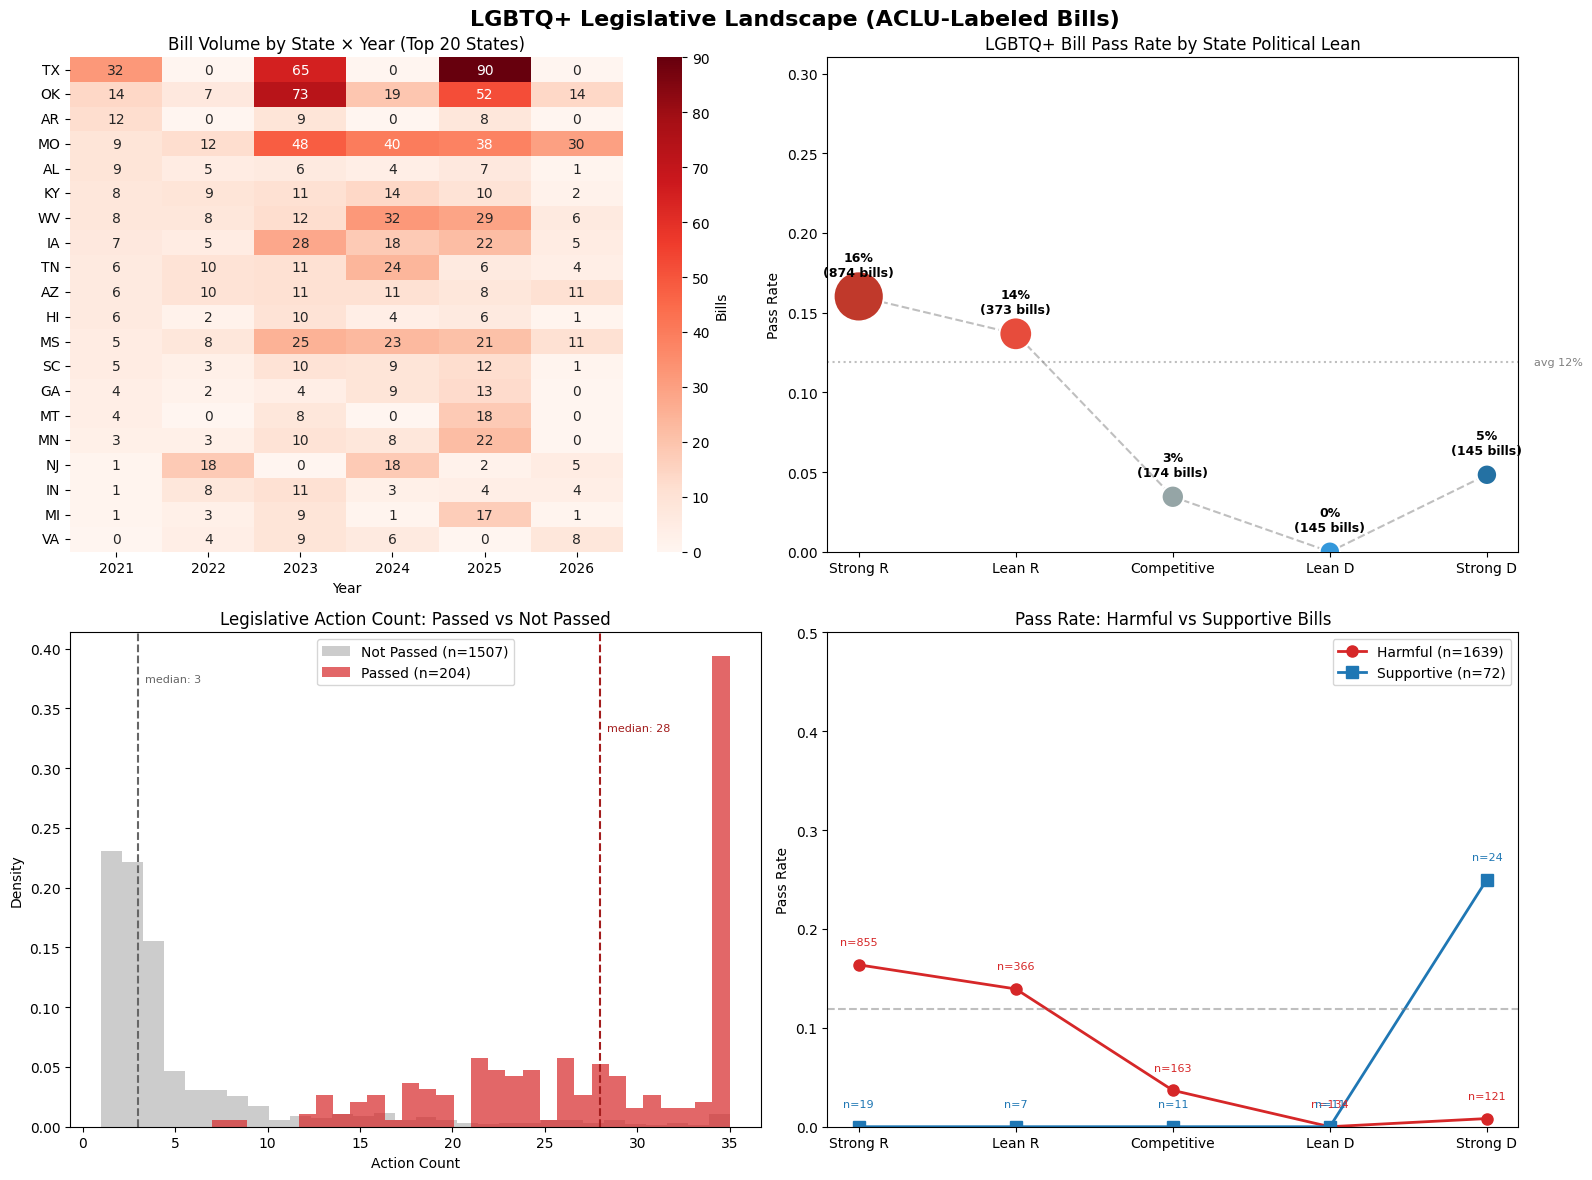


Saved: lgbtq_eda.png


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

aclu_bills = merged[merged['label'].notna()].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('LGBTQ+ Legislative Landscape (ACLU-Labeled Bills)',
             fontsize=16, fontweight='bold')

# ============================================================
# 1. Legislative Wave — Bill Volume by State × Year Heatmap
# ============================================================
ax = axes[0, 0]
pivot = aclu_bills.groupby(['state', 'year']).size().unstack(fill_value=0)
# Top 20 states by total volume
top_states = pivot.sum(axis=1).nlargest(20).index
pivot_top = pivot.loc[top_states].sort_values(
    by=list(pivot.columns), ascending=False)

sns.heatmap(pivot_top, annot=True, fmt='d', cmap='Reds',
            ax=ax, cbar_kws={'label': 'Bills'})
ax.set_title('Bill Volume by State × Year (Top 20 States)')
ax.set_xlabel('Year')
ax.set_ylabel('')

# ============================================================
# 2. Bill Outcomes by State Lean — Pass Rate Dot Plot
# ============================================================
ax = axes[0, 1]
lean_order = ['Strong R', 'Lean R', 'Competitive', 'Lean D', 'Strong D']
lean_colors = ['#c0392b', '#e74c3c', '#95a5a6', '#3498db', '#2471a3']

stats = aclu_bills.groupby('state_lean').agg(
    n_bills=('bill_id', 'count'),
    pass_rate=('passed', 'mean'),
).reindex(lean_order)

ax.scatter(range(len(lean_order)), stats['pass_rate'],
           s=stats['n_bills'] * 1.5, c=lean_colors, zorder=3, edgecolors='white', linewidth=1.5)

# Connect with line
ax.plot(range(len(lean_order)),
        stats['pass_rate'], color='gray', linestyle='--', alpha=0.5, zorder=2)

# Annotate
for i, (lean, row) in enumerate(stats.iterrows()):
    ax.annotate(f"{row['pass_rate']:.0%}\n({int(row['n_bills'])} bills)",
                xy=(i, row['pass_rate']), xytext=(0, 15),
                textcoords='offset points', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(range(len(lean_order)))
ax.set_xticklabels(lean_order)
ax.set_title('LGBTQ+ Bill Pass Rate by State Political Lean')
ax.set_ylabel('Pass Rate')
ax.set_ylim(0, max(stats['pass_rate']) + 0.15)
ax.axhline(y=aclu_bills['passed'].mean(),
           color='gray', linestyle=':', alpha=0.5)
ax.text(4.3, aclu_bills['passed'].mean(), f"avg {aclu_bills['passed'].mean():.0%}",
        fontsize=8, color='gray', va='center')

# ============================================================
# 3. Action Count — Density: Passed vs Not Passed
# ============================================================
ax = axes[1, 0]
cap = int(aclu_bills['action_count'].quantile(0.95))

passed = aclu_bills[aclu_bills['passed'] ==
                    True]['action_count'].clip(upper=cap)
not_passed = aclu_bills[aclu_bills['passed']
                        == False]['action_count'].clip(upper=cap)

ax.hist(not_passed, bins=30, alpha=0.6, color='#aaaaaa',
        label=f'Not Passed (n={len(not_passed)})', density=True)
ax.hist(passed, bins=30, alpha=0.7, color='#d62728',
        label=f'Passed (n={len(passed)})', density=True)

# Add median lines
ax.axvline(not_passed.median(), color='#666666', linestyle='--', linewidth=1.5)
ax.axvline(passed.median(), color='#a31d1d', linestyle='--', linewidth=1.5)

ax.annotate(f'median: {not_passed.median():.0f}', xy=(not_passed.median(), ax.get_ylim()[1] * 0.9),
            fontsize=8, color='#666666', ha='left', xytext=(5, 0), textcoords='offset points')
ax.annotate(f'median: {passed.median():.0f}', xy=(passed.median(), ax.get_ylim()[1] * 0.8),
            fontsize=8, color='#a31d1d', ha='left', xytext=(5, 0), textcoords='offset points')

ax.set_title('Legislative Action Count: Passed vs Not Passed')
ax.set_xlabel('Action Count')
ax.set_ylabel('Density')
ax.legend()

# ============================================================
# 4. Pass Rate Asymmetry — Harmful vs Supportive by State Lean
# ============================================================
ax = axes[1, 1]
pass_rates = aclu_bills.groupby(['state_lean', 'label'])[
    'passed'].agg(['mean', 'count']).reset_index()
pass_rates.columns = ['state_lean', 'label', 'pass_rate', 'n_bills']
pass_rates = pass_rates[pass_rates['n_bills'] >= 3]  # min sample size

for label, color, marker in [('harmful', '#d62728', 'o'), ('supportive', '#1f77b4', 's')]:
    sub = pass_rates[pass_rates['label'] == label].set_index(
        'state_lean').reindex(lean_order)
    ax.plot(range(len(sub)), sub['pass_rate'], marker=marker, color=color,
            label=f'{label.title()} (n={sub["n_bills"].sum():.0f})', linewidth=2, markersize=8)
    # Annotate sample sizes
    for i, (lean, row) in enumerate(sub.iterrows()):
        if pd.notna(row['pass_rate']):
            ax.annotate(f'n={row["n_bills"]:.0f}', xy=(i, row['pass_rate'] + 0.02),
                        ha='center', fontsize=8, color=color)

ax.set_xticks(range(len(lean_order)))
ax.set_xticklabels(lean_order)
ax.set_title('Pass Rate: Harmful vs Supportive Bills')
ax.set_ylabel('Pass Rate')
ax.set_ylim(0, 0.5)
ax.legend()
ax.axhline(y=aclu_bills['passed'].mean(), color='gray',
           linestyle='--', alpha=0.5, label='Overall')

plt.tight_layout()
plt.savefig('lgbtq_eda.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: lgbtq_eda.png")